In [2]:
import numpy as np
import pandas as pd
import sklearn
import opensmile
from datasets import load_from_disk
from tqdm.notebook import tqdm
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from scipy import stats
from scipy.stats import loguniform, pearsonr
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 10,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 10,            # axis-label size matches body text
    'xtick.labelsize'     : 9,             # tick labels one point smaller
    'ytick.labelsize'     : 9,
    'legend.fontsize'     : 9,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    'xtick.minor.size'    : 2,             # half of major — proportional
    'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 300,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})


In [ ]:
woz = pd.read_pickle(r"...\woz.pkl")

In [3]:
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02, #current version, revised from original eGeMAPS
    feature_level=opensmile.FeatureLevel.Functionals, #gets statistical summaries over the whole clip rather than LowLevelDescripts (frame-by-frame time series)
)

In [15]:
sample = woz.iloc[0]
features = smile.process_signal(
    sample['audio']['array'],
    sample['audio']['sampling_rate']
)
print(type(features))
print(features.shape)
print(features.columns.tolist()[:5])

<class 'pandas.DataFrame'>
(1, 88)
['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0']


In [6]:
records = []

for idx, row in tqdm(woz.iterrows(), total=len(woz)):
    features = smile.process_signal(
        row['audio']['array'],
        row['audio']['sampling_rate']
    )
    
    record = {
        'participant': row['participant'],
        'segment_number': row['segment_number'],
        'phq_score': row['phq_score'],
        'split': row['split'],
        'gender': row['gender'],
    }
    
    # add the 88 features
    for name, value in features.iloc[0].items():
        record[name] = value
    
    records.append(record)

woz_features = pd.DataFrame(records)
print(woz_features.shape)

  0%|          | 0/6011 [00:00<?, ?it/s]

(6011, 93)


In [9]:
woz_features.to_pickle(r"...\woz_features")

In [9]:
woz_features = pd.read_pickle(r"...\woz_features")

,participant,segment_number,phq_score,split,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,492,0.0,0,dev,32.459476,0.127084,29.662060,32.069675,34.859688,5.197628,...,-0.011759,0.006834,0.007030,2.351176,1.404917,0.279643,0.257411,0.394138,0.429181,-49.025673
1,492,1.0,0,dev,29.640329,0.109005,28.285152,29.532978,32.000751,3.715599,...,-0.007221,0.002618,0.010657,2.851426,1.705971,0.236765,0.157157,0.328824,0.379626,-47.838284
2,492,2.0,0,dev,29.476030,0.081869,28.111883,29.196026,30.748175,2.636292,...,-0.009746,0.004036,0.011845,3.251626,2.308078,0.243043,0.143237,0.189268,0.199761,-46.271103
3,492,3.0,0,dev,30.120560,0.079050,28.492973,29.677343,31.673737,3.180763,...,-0.009725,0.007440,0.008675,2.351176,1.805416,0.220000,0.176855,0.313889,0.305798,-48.810707
4,492,4.0,0,dev,30.825378,0.106487,28.630680,30.447668,33.970924,5.340244,...,-0.010612,0.004589,0.010592,2.401201,1.805416,0.254444,0.136940,0.271081,0.317267,-46.845509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6006,491,21.0,8,train,29.740639,0.152050,25.089584,29.382435,34.286362,9.196777,...,-0.007399,0.012992,0.007838,2.151076,1.856498,0.205946,0.157179,0.321667,0.769204,-44.753227
6007,491,22.0,8,train,30.344494,0.122782,28.212555,30.069744,32.042049,3.829494,...,-0.008288,0.011588,0.007551,1.600800,1.304566,0.246923,0.174483,0.499231,0.708047,-44.791740
6008,491,23.0,8,train,30.519840,0.122934,26.718548,30.366028,33.987576,7.269028,...,-0.006959,0.011566,0.009317,2.201101,1.354062,0.258148,0.187459,0.443571,0.667972,-46.185310
6009,491,24.0,8,train,29.753126,0.130178,27.789640,29.717810,32.450012,4.660372,...,-0.002819,0.002350,0.027792,2.901451,2.157551,0.257907,0.186866,0.194146,0.195722,-40.089756


In [5]:
# get feature column names
feature_cols = [c for c in woz_features.columns 
                if c not in ['participant', 'segment_number', 'phq_score', 'split', 'gender']]

# split by split column
train = woz_features[woz_features['split'] == 'train']
dev = woz_features[woz_features['split'] == 'dev']
test = woz_features[woz_features['split'] == 'test']

X_train = train[feature_cols].values
y_train = train['phq_score'].values

X_dev = dev[feature_cols].values
y_dev = dev['phq_score'].values

X_test = test[feature_cols].values
y_test = test['phq_score'].values

# scale features - fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# hyperparameter search on dev
magnitudes = []
for i in range(-5, 5):
    magnitude = 1*10**i
    magnitudes.append(magnitude)
    
best_alpha, best_ridge_r = None, -999

for alpha in magnitudes:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_dev_scaled)
    r, p = pearsonr(preds, y_dev)
    if r > best_ridge_r:
        best_ridge_r = r
        best_alpha = alpha
        best_p = p

print(f"Best Ridge alpha: {best_alpha}, dev Pearson r: {best_ridge_r:.3f}, p = {best_p:.3f}")

# same for SVR

#smooth log scale from 0 to y_train.std() [which would be way too large] with 10 steps
epsilons = list(np.logspace(np.log10(1e-3), np.log10(y_train.std()), 10))


best_gamma, best_eps, best_svr_r = None, None, -999

#use same search range as alpha for ridge regression
for gamma in magnitudes:
    for eps in epsilons:
        model = SVR(epsilon=eps, gamma=gamma)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_dev_scaled)
        r, _ = pearsonr(preds, y_dev)
        if r > best_svr_r:
            best_svr_r = r
            best_gamma = gamma
            best_eps = eps
            best_svr_model = model

print(f"Best SVR gamma: {best_gamma}, epsilon: {best_eps}, dev Pearson r: {best_svr_r:.3f}")

In [ ]:
# build a predefined split that respects train/dev split
# -1 = training, 0 = validation
split_index = np.where(
    np.isin(woz_features['split'].values, ['train']), -1, 0
)
# only keep train and dev rows
train_dev_mask = woz_features['split'].isin(['train', 'dev'])
X_traindev = np.vstack([X_train_scaled, X_dev_scaled])
y_traindev = np.concatenate([y_train, y_dev])
split_index = np.array([-1]*len(X_train_scaled) + [0]*len(X_dev_scaled))
ps = PredefinedSplit(split_index)

# Ridge
ridge_search = RandomizedSearchCV(
    Ridge(),
    param_distributions={'alpha': loguniform(1e-5, 1e5)},
    n_iter=50,
    cv=ps,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
ridge_search.fit(X_traindev, y_traindev)
print(f"Best Ridge alpha: {ridge_search.best_params_['alpha']:.4f}")
print(f"Best Ridge dev r2: {ridge_search.best_score_:.3f}")

# SVR
svr_search = RandomizedSearchCV(
    SVR(),
    param_distributions={
        'C': loguniform(1e-5, 1e5),
        'gamma': loguniform(1e-5, 1e5),
        'epsilon': loguniform(1e-3, y_train.std())
    },
    n_iter=50,
    cv=ps,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
svr_search.fit(X_traindev, y_traindev)
print(f"Best SVR params: {svr_search.best_params_}")
print(f"Best SVR dev r2: {svr_search.best_score_:.3f}")

In [31]:
ridge_preds_dev = ridge_search.best_estimator_.predict(X_dev_scaled)
r, p = pearsonr(ridge_preds_dev, y_dev)
print(f"Ridge dev Pearson r: {r:.3f}, p={p:.3f}")

svr_preds_dev = svr_search.best_estimator_.predict(X_dev_scaled)
r, p = pearsonr(svr_preds_dev, y_dev)
print(f"SVR dev Pearson r: {r:.3f}, p={p:.3f}")

Ridge dev Pearson r: 0.340, p=0.000
SVR dev Pearson r: 0.945, p=0.000


In [32]:
# check svr on train to confirm overfitting
svr_preds_train = svr_search.best_estimator_.predict(X_train_scaled)
r_train, _ = pearsonr(svr_preds_train, y_train)
print(f"SVR train Pearson r: {r_train:.3f}")

# and ridge for comparison
ridge_preds_train = ridge_search.best_estimator_.predict(X_train_scaled)
r_train_ridge, _ = pearsonr(ridge_preds_train, y_train)
print(f"Ridge train Pearson r: {r_train_ridge:.3f}")

SVR train Pearson r: 0.919
Ridge train Pearson r: 0.295


In [33]:
print(len(X_train_scaled))
print(len(X_dev_scaled))
print(len(X_traindev))
print(len(split_index))
print(sum(1 for x in split_index if x == -1))  # should equal len(X_train_scaled)
print(sum(1 for x in split_index if x == 0))   # should equal len(X_dev_scaled)

3104
1238
4342
4342
3104
1238


In [ ]:
# get test predictions from both models
ridge_preds_test = ridge_search.best_estimator_.predict(X_test_scaled)
svr_preds_test = svr_search.best_estimator_.predict(X_test_scaled)

# add predictions to test dataframe
test = woz_features[woz_features['split'] == 'test'].copy()
test['ridge_pred'] = ridge_preds_test
test['svr_pred'] = svr_preds_test

# aggregate to participant level by mean
participant_results = test.groupby('participant').agg(
    phq_score=('phq_score', 'first'),
    ridge_mean=('ridge_pred', 'mean'),
    svr_mean=('svr_pred', 'mean'),
).reset_index()

# compute pearson r for both
r_ridge, p_ridge = pearsonr(participant_results['ridge_mean'], participant_results['phq_score'])
r_svr, p_svr = pearsonr(participant_results['svr_mean'], participant_results['phq_score'])

print(f"Ridge test Pearson r: {r_ridge:.3f}, p={p_ridge:.3f}")
print(f"SVR test Pearson r: {r_svr:.3f}, p={p_svr:.3f}")

In [30]:
# save the best ridge model
joblib.dump(ridge_search.best_estimator_, 'best_ridge.joblib')

# save the best svr model
joblib.dump(svr_search.best_estimator_, 'best_svr.joblib')

# save the scaler too since you need it to transform test data later
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [27]:
joblib.dump(best_svr_model, 'best_svr.joblib')
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [9]:
svr = joblib.load('best_svr.joblib')
ridge = joblib.load('best_ridge.joblib')

In [ ]:
# get test predictions from both models
ridge_preds_test = ridge.predict(X_test_scaled)
svr_preds_test = svr.predict(X_test_scaled)

# add predictions to test dataframe
test = woz_features[woz_features['split'] == 'test'].copy()
test['ridge_pred'] = ridge_preds_test
test['svr_pred'] = svr_preds_test

# aggregate to participant level by mean
participant_results = test.groupby('participant').agg(
    phq_score=('phq_score', 'first'),
    ridge_mean=('ridge_pred', 'mean'),
    svr_mean=('svr_pred', 'mean'),
).reset_index()

# compute pearson r for both
r_ridge, p_ridge = pearsonr(participant_results['ridge_mean'], participant_results['phq_score'])
r_svr, p_svr = pearsonr(participant_results['svr_mean'], participant_results['phq_score'])

print(f"Ridge test Pearson r: {r_ridge:.3f}, p={p_ridge:.3f}")
print(f"SVR test Pearson r: {r_svr:.3f}, p={p_svr:.3f}")

In [16]:
model = Ridge(alpha=5)
model.fit(X_train_scaled, y_train)
preds = model.predict(X_dev_scaled)
print(preds.min(), preds.max(), preds.mean(), preds.std())

-3.7951942415906474 31.688500624387057 6.500636542652316 3.5486177233216902


In [17]:
print(y_dev.min(), y_dev.max(), y_dev.mean())

0 23 8.741518578352181


In [19]:
#ESTIMATE NOISE VARIANCE
from sklearn.linear_model import LinearRegression

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
residuals = y_train - ols.predict(X_train_scaled)
sigma2_noise = np.var(residuals)
print(sigma2_noise)

18.531085095852916


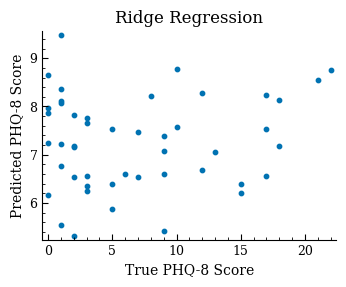

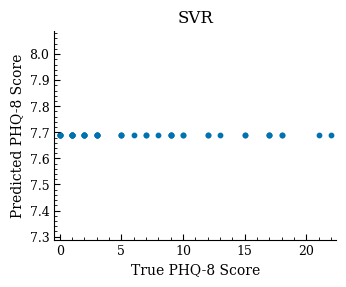

In [37]:
mm = 1 / 25.4

fig, ax = plt.subplots(figsize=(85 * mm, 70 * mm), layout='constrained')
ax.scatter(participant_results['phq_score'], participant_results['ridge_mean'], s=10)
ax.set_xlabel(r'True PHQ-8 Score')
ax.set_ylabel(r'Predicted PHQ-8 Score')
ax.set_title(r'Ridge Regression')
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('ridge_scatter.pdf')

fig, ax = plt.subplots(figsize=(85 * mm, 70 * mm), layout='constrained')
ax.scatter(participant_results['phq_score'], participant_results['svr_mean'], s=10)
ax.set_xlabel(r'True PHQ-8 Score')
ax.set_ylabel(r'Predicted PHQ-8 Score')
ax.set_title(r'SVR')
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('svr_scatter.pdf')

In [12]:
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions={
        'n_estimators': [100, 200, 500],
        'max_depth': [3, 5, 10, None],
        'learning_rate': loguniform(1e-3, 0.3),
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
    },
    n_iter=50,
    cv=ps,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_traindev, y_traindev)

xgb_preds_test = xgb_search.best_estimator_.predict(X_test_scaled)
test_copy = test.copy()
test_copy['xgb_pred'] = xgb_preds_test
xgb_participant = test_copy.groupby('participant').agg(
    phq_score=('phq_score', 'first'),
    xgb_mean=('xgb_pred', 'mean')
).reset_index()
r_xgb, p_xgb = pearsonr(xgb_participant['xgb_mean'], xgb_participant['phq_score'])
print(f"XGBoost test Pearson r: {r_xgb:.3f}, p={p_xgb:.3f}")

XGBoost test Pearson r: 0.163, p=0.272


In [13]:
n = len(xgb_participant)
df = n - 2
print(f"df = {df}")

df = 45


In [12]:
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions={
        'n_estimators': [100, 200, 500],
        'max_depth': [3, 5, 10, None],
        'max_features': ['sqrt', 'log2', 0.5],
        'min_samples_leaf': [1, 2, 5],
    },
    n_iter=50,
    cv=ps,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_traindev, y_traindev)

rf_preds_test = rf_search.best_estimator_.predict(X_test_scaled)
test_copy = test.copy()
test_copy['rf_pred'] = rf_preds_test
rf_participant = test_copy.groupby('participant').agg(
    phq_score=('phq_score', 'first'),
    rf_mean=('rf_pred', 'mean')
).reset_index()
r_rf, p_rf = pearsonr(rf_participant['rf_mean'], rf_participant['phq_score'])
print(f"Random Forest test Pearson r: {r_rf:.3f}, p={p_rf:.3f}")

Random Forest test Pearson r: 0.137, p=0.360


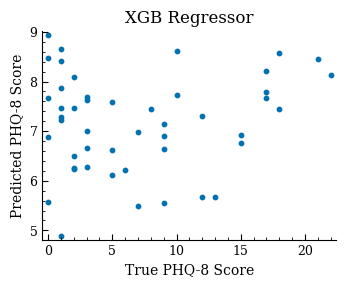

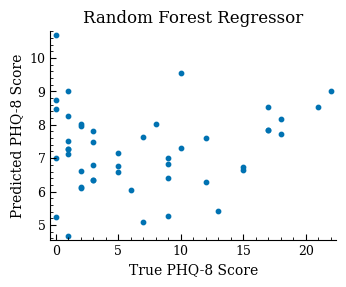

In [14]:
mm = 1 / 25.4

fig, ax = plt.subplots(figsize=(85 * mm, 70 * mm), layout='constrained')
ax.scatter(xgb_participant['phq_score'], xgb_participant['xgb_mean'], s=10)
ax.set_xlabel(r'True PHQ-8 Score')
ax.set_ylabel(r'Predicted PHQ-8 Score')
ax.set_title(r'XGB Regressor')
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('XGB_scatter.pdf')

fig, ax = plt.subplots(figsize=(85 * mm, 70 * mm), layout='constrained')
ax.scatter(rf_participant['phq_score'], rf_participant['rf_mean'], s=10)
ax.set_xlabel(r'True PHQ-8 Score')
ax.set_ylabel(r'Predicted PHQ-8 Score')
ax.set_title(r'Random Forest Regressor')
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('rf_scatter.pdf')